<center> <h1> Netflix Content Segmentation and Exploratory Data Analysis </h1> </center>

In [16]:
from IPython.display import display, HTML

display(HTML("""
<div style="display: flex; justify-content: center;">
    <img src="logo.jpg" width="500"/>
</div>
"""))

In [17]:
#Import required libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Ignore all incoming-warnings (if any):
import warnings
warnings.filterwarnings("ignore")




# load data
df = pd.read_csv("dataset.csv")

# ---------------------------
# 1. Handle missing values
# ---------------------------
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

# drop rows where date_added missing (small count)
df = df.dropna(subset=['date_added'])

# ---------------------------
# 2. Convert date column
# ---------------------------
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# extract useful features
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# ---------------------------
# 3. Clean text columns
# ---------------------------
df['title'] = df['title'].str.strip()
df['description'] = df['description'].str.lower()

# ---------------------------
# 4. Remove duplicates
# ---------------------------
df = df.drop_duplicates(subset='title')

# ---------------------------
# 5. Standardize country (take first country)
# ---------------------------
df['main_country'] = df['country'].apply(lambda x: x.split(',')[0])

# ---------------------------
# 6. Genre cleaning
# ---------------------------
df['main_genre'] = df['genres'].apply(lambda x: x.split(',')[0])

# ---------------------------
# 7. Cast count feature
# ---------------------------
df['cast_count'] = df['cast'].apply(lambda x: 0 if x == 'Unknown' else len(x.split(',')))

# ---------------------------
# 8. Description features
# ---------------------------
df['description_length'] = df['description'].apply(len)
df['description_word_count'] = df['description'].apply(lambda x: len(x.split()))

# ---------------------------
# 9. Content age
# ---------------------------
current_year = 2026
df['content_age'] = current_year - df['release_year']

print(df.head())

  show_id     type                                      title        director  \
0      s1  TV Show                                         3%         Unknown   
1     s10    Movie                                       1920    Vikram Bhatt   
2    s100    Movie                                 3 Heroines  Iman Brotoseno   
3   s1000    Movie  Blue Mountain State: The Rise of Thadland    Lev L. Spiro   
4   s1001  TV Show                             Blue Planet II         Unknown   

                                                cast         country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...          Brazil   
1  Rajneesh Duggal, Adah Sharma, Indraneil Sengup...           India   
2  Reza Rahadian, Bunga Citra Lestari, Tara Basro...       Indonesia   
3  Alan Ritchson, Darin Brooks, James Cade, Rob R...   United States   
4                                 David Attenborough  United Kingdom   

  date_added  release_year rating  duration  \
0 2020-08-14          2020  TV-MA

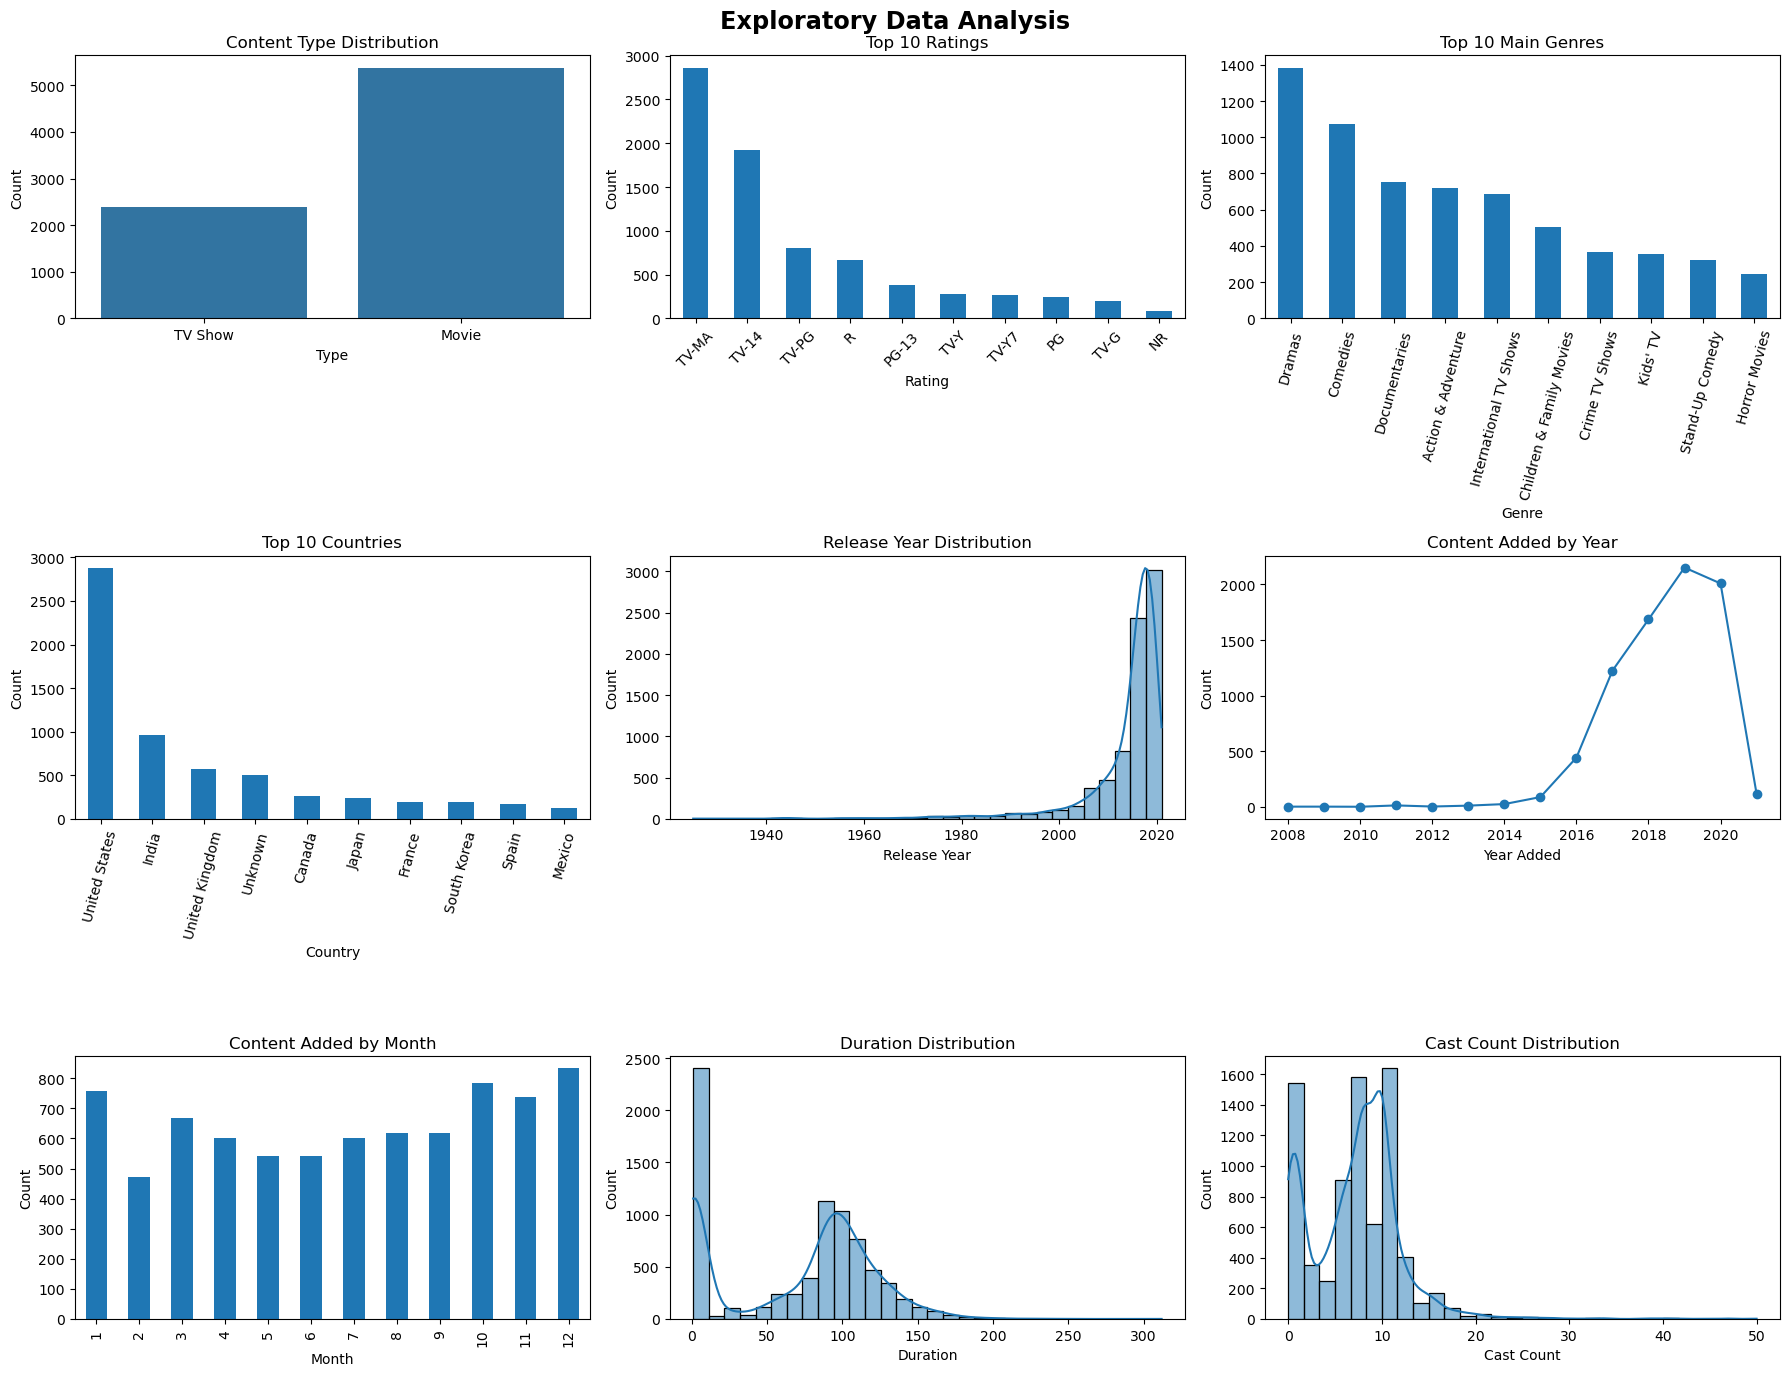

In [18]:
#Simple EDA:


plt.figure(figsize=(18, 14))

plt.suptitle('Exploratory Data Analysis', fontsize='xx-large', fontweight='bold')
# 1. Movie vs TV Show count
plt.subplot(3, 3, 1)
sns.countplot(data=df, x='type')
plt.title("Content Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")

# 2. Top 10 ratings
plt.subplot(3, 3, 2)
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)

# 3. Top 10 genres
plt.subplot(3, 3, 3)
df['main_genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Main Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=75)

# 4. Top 10 countries
plt.subplot(3, 3, 4)
df['main_country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=75)

# 5. Release year distribution
plt.subplot(3, 3, 5)
sns.histplot(df['release_year'], bins=30, kde=True)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Count")

# 6. Content added by year
plt.subplot(3, 3, 6)
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Count")

# 7. Content added by month
plt.subplot(3, 3, 7)
df['month_added'].value_counts().sort_index().plot(kind='bar')
plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Count")

# 8. Duration distribution
plt.subplot(3, 3, 8)
sns.histplot(df['duration'], bins=30, kde=True)
plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Count")

# 9. Cast count distribution
plt.subplot(3, 3, 9)
sns.histplot(df['cast_count'], bins=30, kde=True)
plt.title("Cast Count Distribution")
plt.xlabel("Cast Count")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [19]:

# select useful features
feature_df = df[[
    'type',
    'release_year',
    'duration',
    'main_genre',
    'main_country',
    'cast_count',
    'description_word_count',
    'content_age'
]]

# ---------------------------
# Encode categorical variables
# ---------------------------
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['type', 'main_genre', 'main_country']
num_cols = ['release_year', 'duration', 'cast_count', 'description_word_count', 'content_age']

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X = preprocessor.fit_transform(feature_df)

print("Final Feature Shape:", X.shape)

Final Feature Shape: (7776, 125)


## Q1] Can we identify different types of Netflix content (e.g., casual, premium, niche) using unsupervised learning and visualize these segments to guide investment and user engagement strategies?

Clustering on 7327 titles with 125 features

Cluster Distribution:
Cluster_Label
Mainstream Popular Movies             3488
Niche / Specialized Content           1430
Premium / High-Engagement TV Shows    1251
Casual / Light TV Content             1158
Name: count, dtype: int64


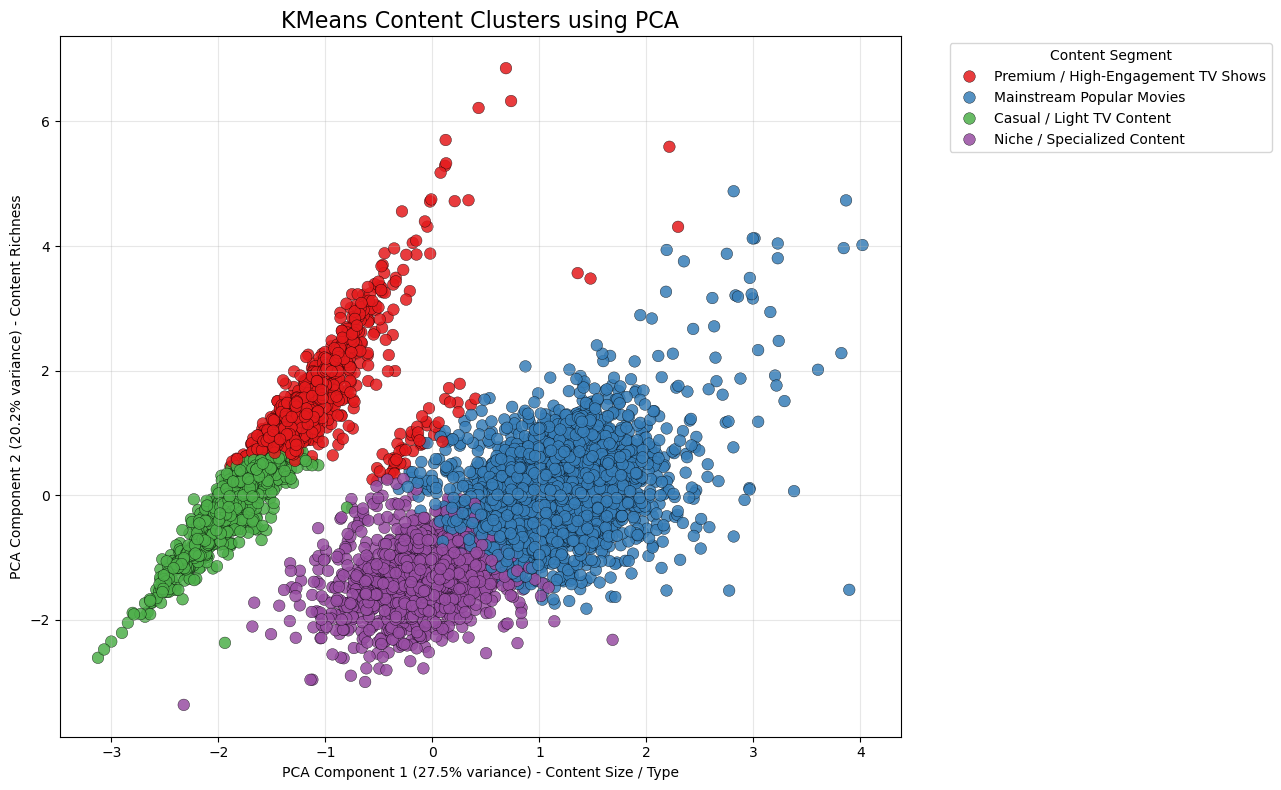


CLUSTER PROFILE

Cluster 0 - Casual / Light TV Content
Total Titles: 1158
Percentage: 15.8%

Average Numeric Values:
release_year: 2016.79
duration: 1.60
cast_count: 3.30
description_word_count: 22.04
content_age: 9.21

Most Common Categories:
Type: TV Show
Genre: International TV Shows
Country: United States

Top 3 Genres:
main_genre
International TV Shows    288
Docuseries                182
Kids' TV                  170
Name: count, dtype: int64

Cluster 1 - Mainstream Popular Movies
Total Titles: 3488
Percentage: 47.6%

Average Numeric Values:
release_year: 2014.53
duration: 106.85
cast_count: 9.05
description_word_count: 24.64
content_age: 11.47

Most Common Categories:
Type: Movie
Genre: Dramas
Country: United States

Top 3 Genres:
main_genre
Dramas                1193
Comedies               931
Action & Adventure     570
Name: count, dtype: int64

Cluster 2 - Niche / Specialized Content
Total Titles: 1430
Percentage: 19.5%

Average Numeric Values:
release_year: 2016.63
duration

In [20]:
# ========================= KMEANS + PCA + CLUSTER PROFILE =========================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# 1. Filter data
df_filtered = df[df['release_year'] > 1999].copy().reset_index(drop=True)

# 2. Transform using existing preprocessor
X_filtered = preprocessor.transform(df_filtered[
    [
        'type',
        'release_year',
        'duration',
        'main_genre',
        'main_country',
        'cast_count',
        'description_word_count',
        'content_age'
    ]
])

print(f"Clustering on {X_filtered.shape[0]} titles with {X_filtered.shape[1]} features")

# 3. Train KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_filtered["Cluster"] = kmeans.fit_predict(X_filtered)

# 4. Create proper cluster labels
cluster_labels = {
    0: "Casual / Light TV Content",
    1: "Mainstream Popular Movies",
    2: "Niche / Specialized Content",
    3: "Premium / High-Engagement TV Shows"
}

df_filtered["Cluster_Label"] = df_filtered["Cluster"].map(cluster_labels)

print("\nCluster Distribution:")
print(df_filtered["Cluster_Label"].value_counts())

# 5. PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_filtered)

# 6. Plot clusters with proper legend
plt.figure(figsize=(13, 8))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df_filtered["Cluster_Label"],
    palette="Set1",
    s=70,
    alpha=0.85,
    edgecolor="k",
    linewidth=0.3
)

plt.title("KMeans Content Clusters using PCA", fontsize=16)
plt.xlabel(
    f"PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance) - Content Size / Type"
)
plt.ylabel(
    f"PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance) - Content Richness"
)

plt.legend(
    title="Content Segment",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Cluster Profile
print("\n" + "=" * 60)
print("CLUSTER PROFILE")
print("=" * 60)

numeric_cols = [
    'release_year',
    'duration',
    'cast_count',
    'description_word_count',
    'content_age'
]

for cluster_no in sorted(df_filtered["Cluster"].unique()):
    subset = df_filtered[df_filtered["Cluster"] == cluster_no]
    label = cluster_labels[cluster_no]

    print(f"\nCluster {cluster_no} - {label}")
    print(f"Total Titles: {len(subset)}")
    print(f"Percentage: {len(subset) / len(df_filtered) * 100:.1f}%")

    print("\nAverage Numeric Values:")
    for col in numeric_cols:
        print(f"{col}: {subset[col].mean():.2f}")

    print("\nMost Common Categories:")
    print(f"Type: {subset['type'].mode()[0]}")
    print(f"Genre: {subset['main_genre'].mode()[0]}")
    print(f"Country: {subset['main_country'].mode()[0]}")

    print("\nTop 3 Genres:")
    print(subset["main_genre"].value_counts().head(3))

In [21]:
# ================= PCA INTERPRETATION =================

# get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# create dataframe of PCA components
pca_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=['PCA1', 'PCA2']
)

# show top contributing features
print("Top features for PCA1:")
print(pca_df.loc['PCA1'].sort_values(ascending=False).head(10))

print("\nTop features for PCA2:")
print(pca_df.loc['PCA2'].sort_values(ascending=False).head(10))

Top features for PCA1:
num__duration                               0.740604
cat__type_Movie                             0.319883
num__description_word_count                 0.295240
num__cast_count                             0.265663
num__content_age                            0.132535
cat__main_genre_Dramas                      0.122980
cat__main_genre_Comedies                    0.092937
cat__main_country_India                     0.082271
cat__main_genre_Action & Adventure          0.062199
cat__main_genre_Children & Family Movies    0.024412
Name: PCA1, dtype: float64

Top features for PCA2:
num__cast_count                             0.721627
num__description_word_count                 0.539396
cat__type_TV Show                           0.179778
cat__main_genre_International TV Shows      0.069086
cat__main_genre_Crime TV Shows              0.036964
cat__main_country_Japan                     0.031266
cat__main_genre_Anime Series                0.026606
cat__main_genre_Kids' TV 

## Q2] Predict whether a content will be “High Engagement” or not:


Model Evaluation:
Accuracy: 63.36760925449872 %
Precision: 0.29020100502512564
Recall: 0.9788135593220338
F1 Score: 0.4476744186046512

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.57      0.73      1320
           1       0.29      0.98      0.45       236

    accuracy                           0.63      1556
   macro avg       0.64      0.78      0.59      1556
weighted avg       0.89      0.63      0.68      1556


Confusion Matrix:
[[755 565]
 [  5 231]]


<Axes: >

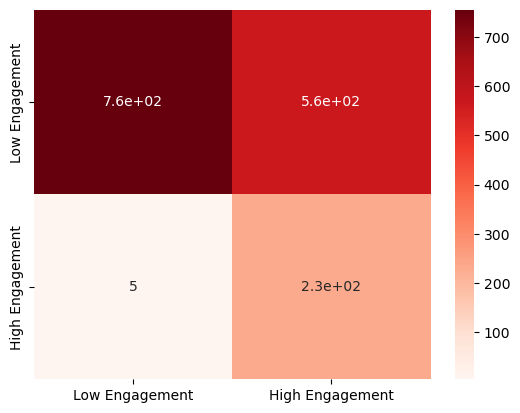

In [22]:
# ========================= DECISION TREE CLASSIFICATION =========================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier , plot_tree


df['high_engagement'] = (
    (df['cast_count'] >= 8) &
    (df['duration'] >= 90) &
    (df['description_word_count'] >= 25)
).astype(int)

X = df[[
    'type',
    'content_age',
    'main_genre',
    'main_country',
    'release_year'
]]

y = df['high_engagement']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



cat_cols_dt = ['type', 'main_genre', 'main_country']
num_cols_dt = ['content_age', 'release_year']

preprocessor_dt = ColumnTransformer([
    ('num', 'passthrough', num_cols_dt),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_dt)
])

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)

y_pred = dt_pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred)*100 ,"%")
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


sns.heatmap(confusion_matrix(y_test, y_pred),annot=True, cmap="Reds",xticklabels=["Low Engagement", "High Engagement"],
            yticklabels=["Low Engagement", "High Engagement"])

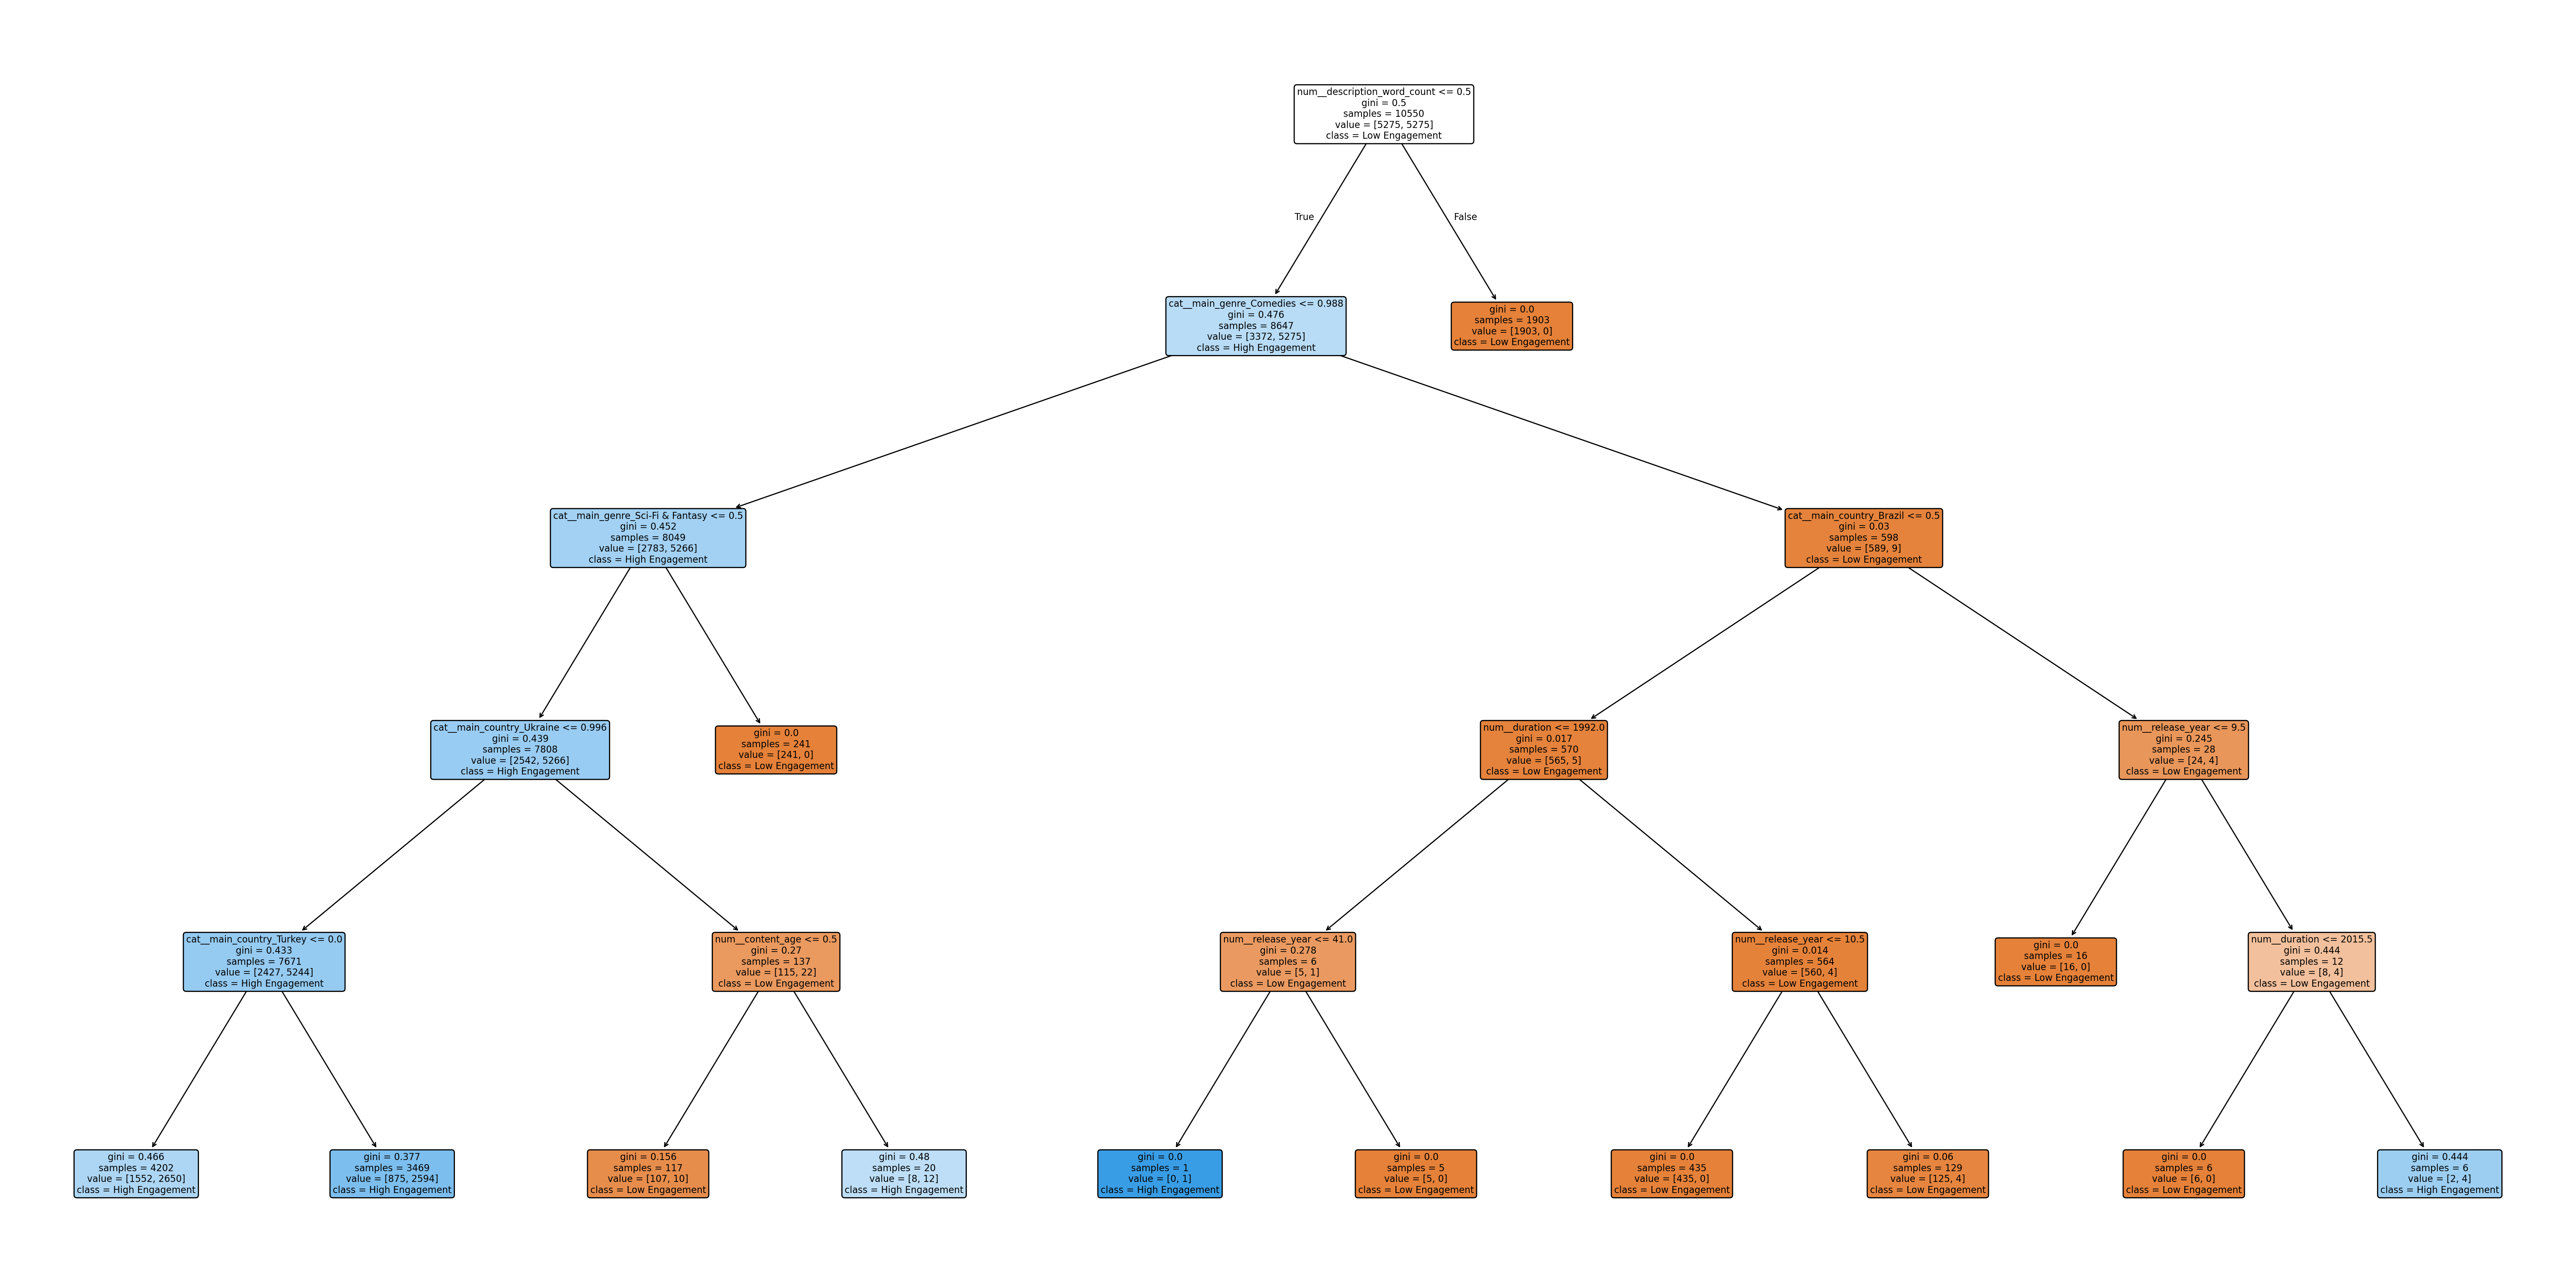

In [23]:
plt.figure(figsize=(40, 20), dpi=200)

plot_tree(
    dt_pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=["Low Engagement", "High Engagement"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=5
)

plt.show()

### INSIGHTS FROM THE ABOVE DECISION TREE:
- **High Engagement *if***: <br>
Description is long <br>
Genre is favorable <br>
Duration is appropriate <br>
Content is relatively recent <br>
    
- **Low Engagement *if***: <br>
Description is short <br>
Certain genres <br>
Less optimal duration <br>
Older content <br>

## Q3] Does premium content require larger casts? (Z-TEST)

In [24]:
from scipy import stats
from statsmodels.stats.weightstats import ztest

premium_cast = df_filtered[df_filtered["Cluster"] == 1]['cast_count'].dropna()

z_stat, p_value = ztest(premium_cast, value=8, alternative='larger')


if p_value < 0.05:
    print("Reject H0: Premium content requires larger casts and hence are most costly.")
    print("""Business Value:
- Netflix should allocate higher budgets to premium content due to larger cast requirements.
- Investing in ensemble casts can improve content richness and viewer engagement.
- Large-cast productions can be prioritized for flagship or high-impact releases.
""")
else:
    print("Fail to Reject H0: Premium content does not requires larger casts")

Reject H0: Premium content requires larger casts and hence are most costly.
Business Value:
- Netflix should allocate higher budgets to premium content due to larger cast requirements.
- Investing in ensemble casts can improve content richness and viewer engagement.
- Large-cast productions can be prioritized for flagship or high-impact releases.



## Q4] Is there a relationship between content type (Movie/TV Show) and genre? (CHI-SQUARE)

In [25]:

contingency_table = pd.crosstab(df['type'], df['main_genre'])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

if p_value < 0.05:
    print("\nReject H0: Content type and genre are related.")
    print("Business Meaning: Genre affects whether a new content is more suitable as a Movie or TV Show.")
else:
    print("\nFail to Reject H0: Content type and genre are independent.")
    print("Business Meaning: Genre does not strongly affect whether a new content should be Movie or TV Show.")



Reject H0: Content type and genre are related.
Business Meaning: Genre affects whether a new content is more suitable as a Movie or TV Show.


## Q5] Do different genres have significantly different average cast sizes? (ANOVA)

In [26]:
from scipy import stats

top_genres = df['main_genre'].value_counts().head(5).index

groups = [
    df[df['main_genre'] == genre]['cast_count'].dropna()
    for genre in top_genres
]

f_stat, p_value = stats.f_oneway(*groups)


if p_value < 0.05:
    print("Reject H0: Different genres have significantly different average cast sizes.")
    print("Result suggests that different genres require different production scales")
else:
    print("Fail to Reject H0:  Different genres dont have significantly different average cast sizes.")

Reject H0: Different genres have significantly different average cast sizes.
Result suggests that different genres require different production scales


## Q6] Is there a significant difference in average cast size between high-engagement and low-engagement content? (T-TEST)

In [27]:

from scipy import stats


high_eng = df[df['high_engagement'] == 1]['cast_count'].dropna()
low_eng = df[df['high_engagement'] == 0]['cast_count'].dropna()

t_stat, p_value = stats.ttest_ind(high_eng, low_eng, equal_var=False)


if p_value < 0.05:
    print("\nReject H0: There is a significant difference in average cast size.")
    print("Hence, Netflix should prioritize multi-character, high-cast productions when aiming to increase viewer retention and engagement.")
else:
    print("\nFail to Reject H0: No significant difference in average cast size.")


Reject H0: There is a significant difference in average cast size.
Hence, Netflix should prioritize multi-character, high-cast productions when aiming to increase viewer retention and engagement.


# Project Conclusion: Netflix Content Segmentation and Engagement Prediction

## What This Project Is About

This project analyzes Netflix content data to understand patterns in movies and TV shows using data cleaning, feature engineering, exploratory data analysis, clustering, PCA visualization, and classification.

The main goal of this project is to convert raw Netflix data into meaningful business insights that can help a streaming platform understand its content library better.

---

## Business Problems Solved

### 1. Content Library Understanding

We analyzed the Netflix dataset to understand:

- Which type of content is more common: Movies or TV Shows
- Which ratings appear most frequently
- Which genres dominate the platform
- Which countries contribute the most content
- How old or recent the available content is

This helps the business understand the current structure of its content library.

---

### 2. Content Segmentation Using KMeans Clustering

We used KMeans clustering to group similar Netflix titles into content segments.

The project identified 4 major content groups:

1. Casual / Light TV Content  
2. Mainstream Popular Movies  
3. Niche / Specialized Content  
4. Premium / High-Engagement TV Shows  

This solves the business problem of content segmentation.

Instead of manually checking thousands of titles, the platform can automatically group content based on features like:

- Content type
- Release year
- Duration
- Genre
- Country
- Cast count
- Description word count
- Content age

---

### 3. PCA-Based Visualization

Because clustering uses many features, it is difficult to visualize directly.

So, PCA was used to reduce the data into 2 dimensions and visualize the clusters clearly.

This helps business teams visually understand how different content groups are separated.

---

### 4. High Engagement Content Prediction

A new target column called `high_engagement` was created using business rules.

Content was marked as high engagement if:

- Cast count is greater than or equal to 8
- Duration is greater than or equal to 90 minutes
- Description word count is greater than or equal to 25

Then, a Decision Tree Classifier was trained to predict whether content is likely to be high engagement or low engagement.

This solves the business problem of predicting potentially valuable content.


---
### 5. Proving Claims to be false or positive using Hypothesis testing:

In this project, hypothesis testing was used to validate key insights derived from exploratory analysis, clustering, and business assumptions. Instead of relying only on visual patterns or model outputs, statistical tests were applied to confirm whether these patterns are significant or just due to randomness.

A Z-test was used to check whether premium content has a significantly higher cast size than a defined benchmark. This helps validate the assumption that high-value content requires larger production scale.

A T-test was performed to compare the average cast size between high-engagement and low-engagement content. The results showed a significant difference, indicating that cast size plays an important role in driving user engagement. This supports the idea that multi-character storytelling contributes to better viewer retention.

A Chi-square test was used to analyze the relationship between content type (Movie or TV Show) and genre. The results confirmed that these variables are not independent, meaning certain genres are more suitable for specific formats. This insight helps guide content production decisions, such as whether a concept should be developed as a movie or a series.

An ANOVA test was applied to determine whether average cast size differs across genres. The results indicated that at least one genre has a significantly different cast size, showing that different genres require different production scales. This helps in optimizing budget allocation and content design.


---


### **Project by:**
- **Name**: Om Satyawan Pathak
- **Email**: omsatyawanpathakwebdevelopment@gmail.com
- **LinkedIn**: www.linkedin.com/in/om-satyawan-pathak-029b02368